# fp2mp_core против бенчмарка fp2mp

Блокнот прогоняет `fp2mp_core` как 7-й baseline `fp2mp` для задач из внешнего бенчмарка [`vasilstar97/fp2mp`](https://github.com/vasilstar97/fp2mp).

Что делает блокнот:

- загружает `problems.json` из raw GitHub и кэширует его локально;
- читает эталонные baseline из локальной read-only копии `examples/data/reference_solutions.json`;
- запускает `from fp2mp_core.graph import run` на выбранных задачах;
- дозаписывает результаты в `data/benchmark/solutions.json` в схеме benchmark `solutions.json`;
- показывает smoke-тест, разбор `log`/токенов и сравнение с готовыми baseline;
- по умолчанию делает один batch-запуск (`LIMIT = 1`), чтобы можно было быстро получить решение и отдельно оценить его LLM-судьёй.

In [1]:
import os
import sys
import hashlib
from pathlib import Path

BASELINE_NAME = "fp2mp"
MODEL = "gpt-4o-mini"
MAX_ITERATIONS = 3
PROBLEMS_URL = "https://raw.githubusercontent.com/vasilstar97/fp2mp/main/examples/data/problems.json"

# По умолчанию один запуск: первая задача benchmark.
# None = все 60 задач; int = первые N задач; list[str] = конкретные problem_id.
LIMIT = 1
PROBLEM_FILTER = None
RUN_SMOKE = False  # True = отдельный платный smoke-вызов run(); False = один LLM-запуск только в batch-ячейке.

# Ручной override (обычно НЕ нужен — ниже есть авто-инвалидизация по сигнатуре synthesis.py).
FORCE_RERUN = False   # True = batch-run заново вызывает run(), игнорируя кэш solutions.json
FORCE_REEVAL = False  # True = evaluate-fp2mp заново судит, игнорируя кэш evaluations_fp2mp.json

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

REFERENCE_SOURCE = Path(r"P:\AI_asistent\ITMO\fp2mp_core\data\benchmark\solutions.json")
REFERENCE_SOLUTIONS = PROJECT_ROOT / "examples" / "data" / "reference_solutions.json"
OUTPUT_SOLUTIONS = PROJECT_ROOT / "data" / "benchmark" / "solutions.json"
PROBLEMS_CACHE = PROJECT_ROOT / "data" / "benchmark" / "problems.json"

# Авто-инвалидизация кэша: сигнатура кода, формирующего финальный ответ (synthesis.py).
# Запись solutions.json хранит synthesis_sig; если он отличается от текущего
# (т.е. synthesis.py менялся) — запись считается устаревшей и перегенерируется
# автоматически при обычном прогоне сверху вниз, без ручного FORCE_RERUN.

def _synthesis_signature():
    p = PROJECT_ROOT / "src" / "fp2mp_core" / "nodes" / "synthesis.py"
    try:
        return hashlib.sha256(p.read_bytes()).hexdigest()[:12]
    except OSError:
        return "unknown"


SYNTHESIS_SIG = _synthesis_signature()

missing_env = [name for name in ("FP2MP_API_KEY", "FP2MP_CHAT_URL") if not os.getenv(name)]
if missing_env:
    print("Не заданы переменные окружения: " + ", ".join(missing_env))
    print("Задайте их перед smoke-тестом и batch-прогоном fp2mp_core.run().")
else:
    print("FP2MP_API_KEY и FP2MP_CHAT_URL заданы.")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"REFERENCE_SOLUTIONS: {REFERENCE_SOLUTIONS}")
print(f"OUTPUT_SOLUTIONS: {OUTPUT_SOLUTIONS}")
print(f"SYNTHESIS_SIG={SYNTHESIS_SIG} | FORCE_RERUN={FORCE_RERUN}, FORCE_REEVAL={FORCE_REEVAL}")

FP2MP_API_KEY и FP2MP_CHAT_URL заданы.
PROJECT_ROOT: p:\AI_asistent\ITMO\fp2mp_core
REFERENCE_SOLUTIONS: p:\AI_asistent\ITMO\fp2mp_core\examples\data\reference_solutions.json
OUTPUT_SOLUTIONS: p:\AI_asistent\ITMO\fp2mp_core\data\benchmark\solutions.json
SYNTHESIS_SIG=45bbc363f19c | FORCE_RERUN=False, FORCE_REEVAL=False


In [2]:
import json
import shutil
import uuid
import urllib.request
from time import perf_counter


def generate_id(*s):
    return uuid.uuid5(uuid.NAMESPACE_DNS, "/".join(s)).hex


def read_json(path, default=None):
    path = Path(path)
    if not path.exists():
        return {} if default is None else default
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def download_json_cached(url, cache_path):
    cache_path = Path(cache_path)
    if cache_path.exists():
        return read_json(cache_path)

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url, timeout=60) as response:
        data = json.loads(response.read().decode("utf-8"))
    write_json(cache_path, data)
    return data


def download_problems(url, cache_path=PROBLEMS_CACHE):
    return download_json_cached(url, cache_path)


def ensure_reference_copy(source=REFERENCE_SOURCE, target=REFERENCE_SOLUTIONS):
    source = Path(source)
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists():
        print(f"Reference copy already exists: {target}")
        return target
    if source.exists():
        shutil.copy2(source, target)
        print(f"Copied reference solutions to: {target}")
        return target
    print(f"Reference source not found, skipping copy: {source}")
    return None


def get_usage_value(message, key):
    usage = None
    if isinstance(message, dict):
        usage = message.get("usage_metadata")
    else:
        usage = getattr(message, "usage_metadata", None)
    return (usage or {}).get(key, 0) or 0


def sum_log_tokens(log, key="total_tokens"):
    return sum(get_usage_value(message, key) for message in (log or []))


def message_type_name(message):
    if isinstance(message, dict):
        return message.get("type") or message.get("name") or "message"
    return type(message).__name__


def message_content(message):
    if isinstance(message, dict):
        return message.get("content", "")
    return getattr(message, "content", "")

In [3]:
ensure_reference_copy()

problems = download_problems(PROBLEMS_URL)
solutions = read_json(OUTPUT_SOLUTIONS, default={})

fp2mp_done = {
    sid
    for sid, item in solutions.items()
    if item.get("baseline") == BASELINE_NAME
    and item.get("model") == MODEL
    and item.get("content")
    and not item.get("error")
}
remaining = len(problems) - len(fp2mp_done)

print(f"Всего задач: {len(problems)}")
print(f"Уже сделано для {BASELINE_NAME}/{MODEL}: {len(fp2mp_done)}")
print(f"Осталось: {remaining}")

Reference copy already exists: p:\AI_asistent\ITMO\fp2mp_core\examples\data\reference_solutions.json
Всего задач: 60
Уже сделано для fp2mp/gpt-4o-mini: 1
Осталось: 59


In [4]:
from langchain_core.messages import BaseMessage
from fp2mp_core.graph import run

smoke_problem_id = next(iter(problems))
smoke_problem = problems[smoke_problem_id]
smoke_solution_id = generate_id(smoke_problem_id, BASELINE_NAME, MODEL)

if RUN_SMOKE:
    print("RUN_SMOKE=True: запускаю отдельный smoke run(); это дополнительный LLM-вызов.", flush=True)
    result = run(input=smoke_problem["content"], model=MODEL, max_iterations=MAX_ITERATIONS)
    assert result["output"], "run() returned empty output"
    assert isinstance(result["log"], list), "run() log must be a list"
    assert all(isinstance(message, BaseMessage) for message in result["log"]), "log items must be BaseMessage"
else:
    print("RUN_SMOKE=False: smoke не вызывает модель. Запустите batch-ячейку ниже для одного LLM-прогона.", flush=True)
    saved = read_json(OUTPUT_SOLUTIONS, default={}).get(smoke_solution_id)
    if saved and saved.get("content") and not saved.get("error"):
        result = {"input": smoke_problem["content"], "output": saved["content"], "log": saved.get("log", [])}
        assert result["output"], "saved result has empty output"
        assert isinstance(result["log"], list), "saved log must be a list"
    else:
        result = None

if result is not None:
    print("input:")
    print(result["input"])
    print("\noutput preview:")
    print(result["output"][:800])
    print(f"\nlen(log): {len(result['log'])}")
    print(f"solution_id: {smoke_solution_id}")

c:\Users\Eynor\AppData\Local\Programs\Python\Python311\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


RUN_SMOKE=False: smoke не вызывает модель. Запустите batch-ячейку ниже для одного LLM-прогона.
input:
Amsterdam. Develop a regional mobility strategy balancing public transport efficiency, suburban accessibility, and environmental sustainability.

output preview:
1. **Direct Answer** — To develop a regional mobility strategy for Amsterdam, focus on enhancing public transport efficiency, increasing cycling usage to 35% by 2030, improving suburban accessibility through integrated metro, tram, and bus services, and expanding electric vehicle infrastructure while implementing low-emission zones to promote environmental sustainability.

2. **Framing** — The problem frame involves creating a comprehensive mobility strategy that addresses the interconnected needs of public transport efficiency, suburban accessibility, and environmental sustainability. This fits the question as it seeks a balanced approach to urban mobility that meets current demands while preparing for future challenges.

3. 

In [5]:
if result is None:
    print("Нет result для разбора. Сначала выполните batch-ячейку или включите RUN_SMOKE=True.")
else:
    total_tokens = 0

    for i, message in enumerate(result["log"], start=1):
        output_tokens = get_usage_value(message, "output_tokens")
        total_tokens += get_usage_value(message, "total_tokens")
        token_part = f" | {output_tokens} output tokens" if output_tokens else ""

        print(f"\n--- message {i}: {message_type_name(message)}{token_part} ---")
        print(message_content(message)[:1200])

    print(f"\nTotal tokens: {total_tokens}")


--- message 1: human ---
Amsterdam. Develop a regional mobility strategy balancing public transport efficiency, suburban accessibility, and environmental sustainability.

--- message 2: ai | 21 output tokens ---
Dispatching 3 agents: ['CodeSpatialAgent', 'WebSearchAgent', 'WebSearchAgent']

--- message 3: ai | 59 output tokens ---
BlackBoard initialised. Question: Amsterdam. Develop a regional mobility strategy balancing public transport efficiency, suburban accessibility, and environmental sustainability.
Sub-queries: ['sq_code_support', 'sq_001', 'sq_002', 'sq_003', 'sq_004', 'sq_005']

--- message 4: ai | 165 output tokens ---
CodeSpatialAgent low-confidence augmentation only. Execution did not complete: "Input to ChatPromptTemplate is missing variables {'place'}.  Expected: ['agent_scratchpad', 'input', 'place'] Received: ['input', 'intermediate_steps', 'agent_scratchpad']\nNote: if you intended {place} to be part of the string and not a variable, please escape it with double curl

In [6]:
def select_problem_ids(problems, limit=LIMIT, problem_filter=PROBLEM_FILTER):
    ids = list(problems.keys())
    if problem_filter is not None:
        if isinstance(problem_filter, str):
            ids = [problem_filter]
        else:
            ids = list(problem_filter)
    if isinstance(limit, int):
        ids = ids[:limit]
    elif isinstance(limit, (list, tuple, set)):
        ids = list(limit)
    return ids


selected_ids = select_problem_ids(problems)
solutions = read_json(OUTPUT_SOLUTIONS, default={})
print(f"Selected problem ids: {selected_ids}", flush=True)
if FORCE_RERUN:
    print("FORCE_RERUN=True: кэш solutions.json игнорируется, run() вызывается заново.", flush=True)

for i, problem_id in enumerate(selected_ids, start=1):
    problem = problems[problem_id]
    solution_id = generate_id(problem_id, BASELINE_NAME, MODEL)
    existing = solutions.get(solution_id, {})

    fresh = (
        existing.get("content")
        and not existing.get("error")
        and existing.get("synthesis_sig") == SYNTHESIS_SIG
    )
    if fresh and not FORCE_RERUN:
        print(f"[{i}/{len(selected_ids)}] {problem_id} skip (актуальный кэш, synthesis_sig={SYNTHESIS_SIG})")
        continue
    if existing.get("content") and existing.get("synthesis_sig") != SYNTHESIS_SIG:
        print(
            f"[{i}/{len(selected_ids)}] {problem_id} устарел "
            f"(sig {existing.get('synthesis_sig')} != {SYNTHESIS_SIG}) → перегенерация",
            flush=True,
        )

    start = perf_counter()
    try:
        print(f"[{i}/{len(selected_ids)}] {problem_id} start run(model={MODEL}, max_iterations={MAX_ITERATIONS})", flush=True)
        result = run(input=problem["content"], model=MODEL, max_iterations=MAX_ITERATIONS)
        log_dump = [message.model_dump() for message in result["log"]]
        solutions[solution_id] = {
            "problem_id": problem_id,
            "baseline": BASELINE_NAME,
            "model": MODEL,
            "content": result["output"],
            "log": log_dump,
            "synthesis_sig": SYNTHESIS_SIG,
        }
        write_json(OUTPUT_SOLUTIONS, solutions)

        elapsed = perf_counter() - start
        tokens = sum_log_tokens(log_dump)
        print(f"[{i}/{len(selected_ids)}] {problem_id} ok ({elapsed:.1f} s, {tokens / 1000:.1f}k токенов)")
    except Exception as exc:
        elapsed = perf_counter() - start
        solutions[solution_id] = {
            "problem_id": problem_id,
            "baseline": BASELINE_NAME,
            "model": MODEL,
            "content": "",
            "log": [],
            "error": str(exc),
            "synthesis_sig": SYNTHESIS_SIG,
        }
        write_json(OUTPUT_SOLUTIONS, solutions)
        print(f"[{i}/{len(selected_ids)}] {problem_id} ERROR after {elapsed:.1f} s: {exc}")

Selected problem ids: ['82fbc85fcfff5fe780b66e3914768cd3']
[1/1] 82fbc85fcfff5fe780b66e3914768cd3 устарел (sig e205d8e75f23 != 45bbc363f19c) → перегенерация
[1/1] 82fbc85fcfff5fe780b66e3914768cd3 start run(model=gpt-4o-mini, max_iterations=3)
[1/1] 82fbc85fcfff5fe780b66e3914768cd3 ok (546.5 s, 9.0k токенов)


In [7]:
import html
from IPython.display import HTML, Markdown, display

reference_solutions = read_json(REFERENCE_SOLUTIONS, default={})
our_solutions = read_json(OUTPUT_SOLUTIONS, default={})
combined_solutions = {**reference_solutions, **our_solutions}

COMPARE_PROBLEM_ID = selected_ids[0] if "selected_ids" in globals() and selected_ids else next(iter(problems))

items = [
    item
    for item in combined_solutions.values()
    if item.get("problem_id") == COMPARE_PROBLEM_ID
]
baseline_order = ["single-agent", "chain-of-thoughts", "generator-critic", "debate", "major-vote", "react", BASELINE_NAME]
items_by_baseline = {item.get("baseline"): item for item in items}

display(Markdown(f"## Problem `{COMPARE_PROBLEM_ID}`"))
display(Markdown(problems[COMPARE_PROBLEM_ID]["content"]))

table = ["| baseline | answer length | output tokens | error |", "|---|---:|---:|---|"]
for baseline in baseline_order:
    item = items_by_baseline.get(baseline)
    if not item:
        table.append(f"| {baseline} | n/a | n/a | missing |")
        continue
    answer_len = len(item.get("content") or "")
    output_tokens = sum_log_tokens(item.get("log") or [], key="output_tokens")
    error = item.get("error", "")
    table.append(f"| {baseline} | {answer_len} | {output_tokens} | {error} |")
display(Markdown("\n".join(table)))

cards = []
for baseline in baseline_order:
    item = items_by_baseline.get(baseline)
    if not item:
        continue
    content = item.get("content") or "_empty_"
    cards.append(
        "<section style='border:1px solid #ddd;border-radius:8px;padding:12px;min-width:320px;flex:1;'>"
        f"<h3 style='margin-top:0'>{html.escape(baseline)}</h3>"
        f"<pre style='white-space:pre-wrap;font-size:13px'>{html.escape(content)}</pre>"
        "</section>"
    )

display(HTML("<div style='display:flex;gap:12px;overflow-x:auto'>" + "".join(cards) + "</div>"))

## Problem `82fbc85fcfff5fe780b66e3914768cd3`

Amsterdam. Develop a regional mobility strategy balancing public transport efficiency, suburban accessibility, and environmental sustainability.

| baseline | answer length | output tokens | error |
|---|---:|---:|---|
| single-agent | 7126 | 2070 |  |
| chain-of-thoughts | 4763 | 2918 |  |
| generator-critic | 10769 | 7406 |  |
| debate | 7497 | 27667 |  |
| major-vote | 7121 | 9910 |  |
| react | 10794 | 11176 |  |
| fp2mp | 4893 | 9000 |  |

## Оценка качества (LLM-судья)

Следующие ячейки запускают judge-панель из [`vasilstar97/fp2mp-eval`](https://github.com/vasilstar97/fp2mp-eval) для одного решения `fp2mp` и сравнивают его с готовыми baseline по баллам.

Это платный этап: `N_JUDGES` LLM-вызовов на одну задачу. Для сравнимости с benchmark используется `JUDGE_MODEL = "openai/gpt-4.1"` и `N_JUDGES = 5`.

Если пакет не установлен, выполните в окружении notebook:

```bash
pip install git+https://github.com/vasilstar97/fp2mp-eval
```

In [8]:
JUDGE_MODEL = "openai/gpt-4.1"  # как в benchmark bench_evaluations.json (сопоставимость)
JUDGE_TEMPERATURE = 0.5
N_JUDGES = 5
EVAL_MAX_WORKERS = 5

BENCH_SOLUTIONS_URL = "https://raw.githubusercontent.com/vasilstar97/fp2mp/main/examples/data/solutions.json"
BENCH_EVALUATIONS_URL = "https://raw.githubusercontent.com/vasilstar97/fp2mp/main/examples/data/evaluations.json"
BENCH_SOLUTIONS_CACHE = PROJECT_ROOT / "data" / "benchmark" / "bench_solutions.json"
BENCH_EVALUATIONS_CACHE = PROJECT_ROOT / "data" / "benchmark" / "bench_evaluations.json"
OUTPUT_EVALUATIONS = PROJECT_ROOT / "data" / "benchmark" / "evaluations_fp2mp.json"

print(f"Judge: {JUDGE_MODEL}, n_judges={N_JUDGES}, max_workers={EVAL_MAX_WORKERS}")
print(f"OUTPUT_EVALUATIONS: {OUTPUT_EVALUATIONS}")

Judge: openai/gpt-4.1, n_judges=5, max_workers=5
OUTPUT_EVALUATIONS: p:\AI_asistent\ITMO\fp2mp_core\data\benchmark\evaluations_fp2mp.json


In [9]:
try:
    from fp2mp_eval.core import FP2MPEval
except ImportError as exc:
    print("Пакет fp2mp-eval не установлен.")
    print("Установите его в окружении notebook:")
    print("pip install git+https://github.com/vasilstar97/fp2mp-eval")
    raise

print("fp2mp_eval импортирован.")

fp2mp_eval импортирован.


In [10]:
import hashlib


def find_fp2mp_solution(solutions, selected_ids=None):
    candidate_ids = list(selected_ids or [])
    candidate_ids.extend(pid for pid in problems.keys() if pid not in candidate_ids)

    for problem_id in candidate_ids:
        solution_id = generate_id(problem_id, BASELINE_NAME, MODEL)
        item = solutions.get(solution_id)
        if item and item.get("content") and not item.get("error"):
            return problem_id, solution_id, item
    raise RuntimeError("Не найдено готовое fp2mp-решение. Сначала выполните batch-прогон с LIMIT=1.")


our_solutions = read_json(OUTPUT_SOLUTIONS, default={})
EVAL_PROBLEM_ID, EVAL_SOLUTION_ID, fp2mp_solution = find_fp2mp_solution(
    our_solutions,
    selected_ids if "selected_ids" in globals() else None,
)
eval_key = generate_id(EVAL_SOLUTION_ID, JUDGE_MODEL)
# Сигнатура оцениваемого контента: если решение перегенерировано (синтез изменился),
# контент-хэш меняется и старая оценка автоматически считается устаревшей.
sol_sig = hashlib.sha256(fp2mp_solution["content"].encode("utf-8")).hexdigest()[:12]
evaluations_fp2mp = read_json(OUTPUT_EVALUATIONS, default={})

cached_eval = evaluations_fp2mp.get(eval_key, {})
eval_fresh = (
    cached_eval.get("content")
    and cached_eval.get("solution_content_sig") == sol_sig
)
if eval_fresh and not FORCE_REEVAL:
    print(f"Evaluation актуальна, skip: {eval_key} (solution_content_sig={sol_sig})")
else:
    if cached_eval.get("content") and cached_eval.get("solution_content_sig") != sol_sig:
        print(
            f"Решение изменилось (sig {cached_eval.get('solution_content_sig')} != {sol_sig}) "
            "→ переоценка судьёй.",
            flush=True,
        )
    print(f"Evaluating problem_id={EVAL_PROBLEM_ID}, solution_id={EVAL_SOLUTION_ID}")
    case = (problems[EVAL_PROBLEM_ID]["content"], fp2mp_solution["content"])
    evaluator = FP2MPEval(model=JUDGE_MODEL, temperature=JUDGE_TEMPERATURE, n_judges=N_JUDGES)
    try:
        evals = evaluator.evaluate_case(case=case, max_workers=EVAL_MAX_WORKERS)
    except Exception as exc:
        msg = str(exc)
        if len(msg) > 1200:
            msg = f"{msg[:1200]}..."
        print("Judge провайдер отклонил запрос или вернул ошибку; оценка не сохранена.")
        print(f"Ошибка судьи: {msg}")
        print("Смените JUDGE_MODEL или повторите запуск позже.")
    else:
        evaluations_fp2mp[eval_key] = {
            "solution_id": EVAL_SOLUTION_ID,
            "model": JUDGE_MODEL,
            "solution_content_sig": sol_sig,
            "content": [evaluation.model_dump() for evaluation in evals],
        }
        write_json(OUTPUT_EVALUATIONS, evaluations_fp2mp)
        print(f"Saved evaluation: {OUTPUT_EVALUATIONS}")

print(f"EVAL_PROBLEM_ID: {EVAL_PROBLEM_ID}")
print(f"EVAL_SOLUTION_ID: {EVAL_SOLUTION_ID}")

Решение изменилось (sig 0d7ee50e57b4 != bc98dcfd8459) → переоценка судьёй.
Evaluating problem_id=82fbc85fcfff5fe780b66e3914768cd3, solution_id=86f4e7e4d2d159549f57dc44715427b2
Saved evaluation: p:\AI_asistent\ITMO\fp2mp_core\data\benchmark\evaluations_fp2mp.json
EVAL_PROBLEM_ID: 82fbc85fcfff5fe780b66e3914768cd3
EVAL_SOLUTION_ID: 86f4e7e4d2d159549f57dc44715427b2


## Score comparison for `82fbc85fcfff5fe780b66e3914768cd3`

baseline,single-agent,chain-of-thoughts,generator-critic,debate,major-vote,react,fp2mp
criterion,,,,,,,
coherence,4.20 ± 0.45,4.00 ± 0.00,4.20 ± 0.45,4.00 ± 0.00,4.00 ± 0.00,4.40 ± 0.55,4.80 ± 0.45
decomposition,4.20 ± 0.45,4.00 ± 0.00,4.20 ± 0.45,4.00 ± 0.00,4.00 ± 0.00,4.20 ± 0.45,4.00 ± 0.00
diversity,3.60 ± 0.55,2.60 ± 0.55,3.00 ± 0.00,2.60 ± 0.55,3.20 ± 0.45,3.00 ± 0.00,3.40 ± 0.55
framing,4.20 ± 0.45,4.00 ± 0.00,4.20 ± 0.45,4.00 ± 0.00,4.00 ± 0.00,4.00 ± 0.00,4.00 ± 0.00
justification,4.00 ± 0.00,3.00 ± 0.00,4.00 ± 0.00,3.00 ± 0.00,3.40 ± 0.55,3.40 ± 0.55,4.00 ± 0.00
knowledge_integration,4.20 ± 0.45,4.00 ± 0.00,4.20 ± 0.45,4.00 ± 0.00,4.00 ± 0.00,4.60 ± 0.55,4.80 ± 0.45
metacognition,3.20 ± 0.45,2.20 ± 0.45,3.60 ± 0.55,3.00 ± 0.00,3.00 ± 0.00,2.00 ± 0.00,4.60 ± 0.55
uncertainty_handling,3.20 ± 0.45,3.00 ± 0.00,4.20 ± 0.45,3.00 ± 0.00,2.80 ± 0.45,2.00 ± 0.00,4.00 ± 0.00
mean_over_8_dimensions,3.85 ± 0.45,3.35 ± 0.74,3.95 ± 0.44,3.45 ± 0.60,3.55 ± 0.51,3.45 ± 1.04,4.20 ± 0.49


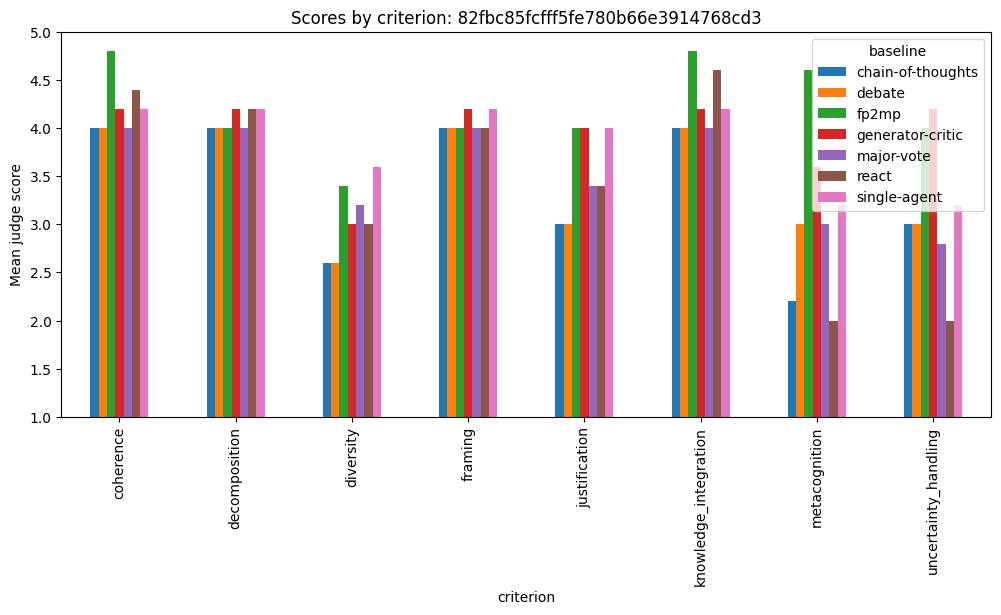

In [11]:
import pandas as pd
from IPython.display import Markdown, display

bench_solutions = download_json_cached(BENCH_SOLUTIONS_URL, BENCH_SOLUTIONS_CACHE)
bench_evaluations = download_json_cached(BENCH_EVALUATIONS_URL, BENCH_EVALUATIONS_CACHE)
our_solutions = read_json(OUTPUT_SOLUTIONS, default={})
our_evaluations = read_json(OUTPUT_EVALUATIONS, default={})

all_solutions = {**bench_solutions, **our_solutions}
all_evaluations = {**bench_evaluations, **our_evaluations}
target_problem_id = EVAL_PROBLEM_ID if "EVAL_PROBLEM_ID" in globals() else COMPARE_PROBLEM_ID
baseline_order = globals().get(
    "baseline_order",
    ["single-agent", "chain-of-thoughts", "generator-critic", "debate", "major-vote", "react", BASELINE_NAME],
)

# Сопоставимость: benchmark baseline сгенерированы на этой модели и судились этим судьёй.
BENCH_MODEL = "gpt-4o-mini"
BENCH_JUDGE = "openai/gpt-4.1"
if MODEL != BENCH_MODEL or JUDGE_MODEL != BENCH_JUDGE:
    display(Markdown(
        "> ⚠️ **Сравнение индикативно, не apples-to-apples.** "
        f"fp2mp: model=`{MODEL}`, judge=`{JUDGE_MODEL}`; "
        f"benchmark: model=`{BENCH_MODEL}`, judge=`{BENCH_JUDGE}`. "
        "Для строгого сравнения выставьте `MODEL` и `JUDGE_MODEL` как в benchmark "
        "и перегенерируйте (`FORCE_RERUN`/`FORCE_REEVAL`)."
    ))

rows = []
for evaluation in all_evaluations.values():
    solution_id = evaluation.get("solution_id")
    solution = all_solutions.get(solution_id)
    if not solution or solution.get("problem_id") != target_problem_id:
        continue
    if solution.get("baseline") == BASELINE_NAME and evaluation.get("model") != JUDGE_MODEL:
        # Do not merge stale/incompatible fp2mp judge runs into the comparison.
        continue

    for judge_index, judge_result in enumerate(evaluation.get("content") or [], start=1):
        for criterion, dimension in judge_result.items():
            if not isinstance(dimension, dict) or "score" not in dimension:
                continue
            rows.append({
                "baseline": solution.get("baseline"),
                "problem_id": solution.get("problem_id"),
                "criterion": criterion,
                "judge": judge_index,
                "score": int(dimension["score"]),
            })

scores = pd.DataFrame(rows)
if scores.empty:
    raise RuntimeError(f"Нет оценок для problem_id={target_problem_id}. Выполните ячейку оценки fp2mp и проверьте benchmark evaluations cache.")

summary = (
    scores.groupby(["criterion", "baseline"])["score"]
    .agg(["mean", "std"])
    .reset_index()
)
summary["mean_std"] = summary.apply(
    lambda row: f"{row['mean']:.2f} ± {0 if pd.isna(row['std']) else row['std']:.2f}",
    axis=1,
)
pivot = summary.pivot(index="criterion", columns="baseline", values="mean_std")

criterion_means = scores.groupby(["baseline", "criterion"])["score"].mean().reset_index()
overall = criterion_means.groupby("baseline")["score"].agg(["mean", "std"])
overall_display = overall.apply(
    lambda row: f"{row['mean']:.2f} ± {0 if pd.isna(row['std']) else row['std']:.2f}",
    axis=1,
)
pivot.loc["mean_over_8_dimensions"] = overall_display

display(Markdown(f"## Score comparison for `{target_problem_id}`"))
display(pivot.reindex(columns=[baseline for baseline in baseline_order if baseline in pivot.columns]))

try:
    ax = criterion_means.pivot(index="criterion", columns="baseline", values="score").plot(kind="bar", figsize=(12, 5))
    ax.set_ylim(1, 5)
    ax.set_ylabel("Mean judge score")
    ax.set_title(f"Scores by criterion: {target_problem_id}")
except Exception as exc:
    print(f"Barplot skipped: {exc}")

## Как влить результат в pipeline benchmark

После полного прогона `LIMIT=None` результаты лежат в `data/benchmark/solutions.json`, а локальные оценки fp2mp — в `data/benchmark/evaluations_fp2mp.json`.

Чтобы использовать стандартный pipeline `vasilstar97/fp2mp`:

1. Смержить записи из `data/benchmark/solutions.json` в `data/solutions.json` репозитория `vasilstar97/fp2mp`.
2. Запустить `2_evaluation.ipynb` в репозитории benchmark для полного платного judge-прогона.
3. Запустить `3_results.ipynb` для агрегации результатов.

Полный платный прогон судьи пользователь запускает отдельно.